In [439]:
!pip install ipynb

In [440]:
import pandas as pd
import time
import numpy as np
from scipy.spatial.distance import cdist
from scipy.cluster.vq import kmeans2, whiten
import matplotlib.pyplot as plt
from scipy.spatial.distance import euclidean
import math


In [441]:
df_coords = pd.read_excel("Spring25Project_Data.xlsx", sheet_name="coordinates")
df_demand=pd.read_excel("Spring25Project_Data.xlsx",sheet_name="demands")

In [442]:
df_demand

,Node ID,Demand
0,0,0
1,1,18
2,2,16
3,3,22
4,4,24
5,5,3
6,6,19
7,7,6
8,8,6
9,9,6


In [443]:
df_coords

,Node ID,x-coordinate,y-coordinate
0,0,39,19
1,1,79,19
2,2,41,79
3,3,25,31
4,4,63,93
5,5,33,5
6,6,69,17
7,7,57,73
8,8,53,75
9,9,1,1


In [444]:
df_coords.describe()

,Node ID,x-coordinate,y-coordinate
count,39.000000,39.000000,39.000000
mean,19.000000,48.487179,44.948718
std,11.401754,29.801865,30.294996
min,0.000000,1.000000,1.000000
25%,9.500000,24.000000,19.000000
50%,19.000000,45.000000,41.000000
75%,28.500000,79.000000,73.000000
max,38.000000,93.000000,97.000000


In [445]:
df_coords.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39 entries, 0 to 38
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Node ID       39 non-null     int64
 1   x-coordinate  39 non-null     int64
 2   y-coordinate  39 non-null     int64
dtypes: int64(3)
memory usage: 1.0 KB


In [446]:
df_coords.shape

(39, 3)

In [447]:
nodes = list(range(df_coords.shape[0]))

In [448]:
print(nodes)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38]


In [449]:
node_coordinates = {i: (df_coords["x-coordinate"][i], df_coords["y-coordinate"][i])
                    for i in nodes}

In [450]:
node_coordinates
aa = [(df_coords["x-coordinate"][i], df_coords["y-coordinate"][i]) for i in nodes]
coordinates = np.asarray(aa)
print(coordinates)

[[39 19]
 [79 19]
 [41 79]
 [25 31]
 [63 93]
 [33  5]
 [69 17]
 [57 73]
 [53 75]
 [ 1  1]
 [79 73]
 [59  5]
 [ 1 37]
 [41 31]
 [23 73]
 [37 27]
 [85 93]
 [93 13]
 [85 45]
 [49 91]
 [55 43]
 [83 29]
 [93 49]
 [87 23]
 [31 23]
 [19 97]
 [41  9]
 [83 61]
 [ 9  7]
 [13 13]
 [43 37]
 [13 61]
 [71 51]
 [45 93]
 [93 55]
 [ 5 97]
 [81 11]
 [ 7 53]
 [ 7 41]]


In [451]:
distance_matrix = cdist(coordinates, coordinates, metric='euclidean')
distance_df = pd.DataFrame(distance_matrix)
print(distance_df)

           0           1          2          3           4           5   \
0    0.000000   40.000000  60.033324  18.439089   77.794601   15.231546   
1   40.000000    0.000000  71.021124  55.317267   75.709973   48.083261   
2   60.033324   71.021124   0.000000  50.596443   26.076810   74.431176   
3   18.439089   55.317267  50.596443   0.000000   72.718636   27.202941   
4   77.794601   75.709973  26.076810  72.718636    0.000000   92.973114   
5   15.231546   48.083261  74.431176  27.202941   92.973114    0.000000   
6   30.066593   10.198039  68.029405  46.173586   76.236474   37.947332   
7   56.920998   58.309519  17.088007  52.801515   20.880613   72.111026   
8   57.723479   61.741396  12.649111  52.153619   20.591260   72.801099   
9   42.047592   80.049984  87.658428  38.418745  110.941426   32.249031   
10  67.201190   54.000000  38.470768  68.410526   25.612497   82.097503   
11  24.413111   24.413111  76.157731  42.801869   88.090862   26.000000   
12  42.047592   80.049984

In [452]:
vehicle_capacity = 85
demands = df_demand["Demand"].values
total_demand = df_demand["Demand"].sum()
num_vehicles = int(np.ceil(total_demand / vehicle_capacity))
depot=0
num_vehicles

7

In [453]:
start_time_sweep = time.time()
angles = []
for i in range(len(coordinates)):
    if i == depot:
        continue
    dx = coordinates[i][0] - coordinates[depot][0]
    dy = coordinates[i][1] - coordinates[depot][1]
    angle = math.degrees(math.atan2(dy, dx)) % 360
    angles.append((i, angle))

sorted_nodes = [i for i, _ in sorted(angles, key=lambda x: x[1])]

clusters = []
current_cluster = {depot}
current_demand = 0

for i in sorted_nodes:
    demand = demands[i]
    if current_demand + demand <= vehicle_capacity:
        current_cluster.add(i)
        current_demand += demand
    else:
        clusters.append(current_cluster)
        current_cluster = {depot, i}
        current_demand = demand

clusters.append(current_cluster)

while len(clusters) < num_vehicles:
    clusters.append({depot})

for i, cluster in enumerate(clusters):
    total_d = df_demand.loc[list(cluster), "Demand"].sum()
    print(f"Vehicle {i+1} → Nodes: {cluster}, Total Demand: {total_d}")

end_time_sweep = time.time()
total_time_sweep = round(end_time_sweep - start_time_sweep, 5)

print(f"Total combination time: {total_time_sweep} seconds")
print(f"Total vehicles used: {len(clusters)} (minimum required: {num_vehicles})")


Vehicle 1 → Nodes: {0, 1, 34, 32, 18, 21, 22, 23, 27}, Total Demand: 84
Vehicle 2 → Nodes: {0, 4, 7, 8, 10, 16, 20}, Total Demand: 78
Vehicle 3 → Nodes: {0, 13, 30}, Total Demand: 81
Vehicle 4 → Nodes: {0, 33, 2, 15, 19, 25}, Total Demand: 80
Vehicle 5 → Nodes: {0, 35, 3, 37, 38, 14, 24, 31}, Total Demand: 80
Vehicle 6 → Nodes: {0, 5, 9, 11, 12, 26, 28, 29}, Total Demand: 85
Vehicle 7 → Nodes: {0, 17, 36, 6}, Total Demand: 38
Total combination time: 0.00707 seconds
Total vehicles used: 7 (minimum required: 7)


In [454]:

#def nearest_neighbor(cluster, depot, distance_matrix):
 #   tour = [depot]
  #  unvisited = set(cluster)
   # current = depot
    #total_distance = 0

    #while unvisited:
     #   min_dist = float('inf')
      #  next_node = None

       # for node in unvisited:
        #    dist = distance_matrix[current][node]
         #   if dist < min_dist:
          #      min_dist = dist
           #     next_node = node

        #total_distance += min_dist
        #tour.append(next_node)
        #print(f"Added {next_node} to the tour!")
        #current = next_node
        #unvisited.remove(next_node)

    #total_distance += distance_matrix[current][depot]
    #tour.append(depot)

    #return tour, total_distance

In [455]:
start_time_nnh=time.time()

from ipynb.fs.full.VRPlib import nearest_neighbor
vrp_solution = []
vrp_total_distance = 0

for c in clusters:
    tour, tour_length = nearest_neighbor(c, depot, distance_df)
    vrp_solution.append(tour)
    vrp_total_distance += tour_length

end_time_nnh = time.time()
total_time_nnh = round(end_time_nnh - start_time_nnh, 5)

print()
print(f"Total combination time: {total_time_nnh} seconds")
print("The VRP solution is:")
for tour in vrp_solution:
    print(tour)
print("with total distance", vrp_total_distance)

Added 1 to the tour!
Added 23 to the tour!
Added 21 to the tour!
Added 18 to the tour!
Added 22 to the tour!
Added 34 to the tour!
Added 27 to the tour!
Added 32 to the tour!
Added 20 to the tour!
Added 7 to the tour!
Added 8 to the tour!
Added 4 to the tour!
Added 16 to the tour!
Added 10 to the tour!
Added 13 to the tour!
Added 30 to the tour!
Added 15 to the tour!
Added 2 to the tour!
Added 19 to the tour!
Added 33 to the tour!
Added 25 to the tour!
Added 24 to the tour!
Added 3 to the tour!
Added 38 to the tour!
Added 37 to the tour!
Added 31 to the tour!
Added 14 to the tour!
Added 35 to the tour!
Added 26 to the tour!
Added 5 to the tour!
Added 29 to the tour!
Added 28 to the tour!
Added 9 to the tour!
Added 12 to the tour!
Added 11 to the tour!
Added 6 to the tour!
Added 36 to the tour!
Added 17 to the tour!

Total combination time: 0.00348 seconds
The VRP solution is:
[0, 1, 23, 21, 18, 22, 34, 27, 32, 0]
[0, 20, 7, 8, 4, 16, 10, 0]
[0, 13, 30, 0]
[0, 15, 2, 19, 33, 25, 0]
[0, 

In [456]:
def calculate_tour_cost(tour, distance_matrix):
    cost = 0
    for i in range(len(tour) - 1):
        cost += distance_matrix[tour[i]][tour[i+1]]
    return cost

start_time_nongreedy2opt = time.time()
def two_opt_full_search(tour, distance_matrix):
    n = len(tour) - 1
    best_tour = tour[:]
    best_cost = calculate_tour_cost(best_tour, distance_matrix)

    improved = True
    while improved:
        improved = False
        local_best_tour = best_tour[:]
        local_best_cost = best_cost

        for i in range(1, n - 1):
            for j in range(i + 1, n):
                new_tour = best_tour[:]
                new_tour[i:j+1] = new_tour[i:j+1][::-1]
                new_cost = calculate_tour_cost(new_tour, distance_matrix)

                if new_cost < local_best_cost:
                    local_best_cost = new_cost
                    local_best_tour = new_tour[:]

        if local_best_cost < best_cost:
            best_tour = local_best_tour[:]
            best_cost = local_best_cost
            improved = True

    return best_tour, best_cost
nongreedy_optimized_routes = {}
nongreedy_optimized_costs = {}
nongreedy_total_cost = 0

for c, route in enumerate(vrp_solution):
    improved_route, improved_cost = two_opt_full_search(route, distance_matrix)
    nongreedy_optimized_routes[c] = improved_route
    nongreedy_optimized_costs[c] = improved_cost
    nongreedy_total_cost += improved_cost

end_time_nongreedy2opt = time.time()
total_time_nongreedy2opt = round(end_time_nongreedy2opt - start_time_nongreedy2opt, 5)

for c, (route, cost) in enumerate(nongreedy_optimized_costs.items()):
    route_str = " → ".join(map(str, nongreedy_optimized_routes[c]))
    print(f"Cluster {c}: Route → {route_str} | Cost = {cost:.2f}")


print(f"\nTotal cost after non-greedy 2-opt optimization: {nongreedy_total_cost:.2f}")
print(f"Total combination time: {total_time_nongreedy2opt} seconds")


Cluster 0: Route → 0 → 1 → 23 → 21 → 18 → 22 → 34 → 27 → 32 → 0 | Cost = 159.76
Cluster 1: Route → 0 → 20 → 10 → 16 → 4 → 8 → 7 → 0 | Cost = 192.13
Cluster 2: Route → 0 → 13 → 30 → 0 | Cost = 36.93
Cluster 3: Route → 0 → 15 → 25 → 33 → 19 → 2 → 0 | Cost = 185.76
Cluster 4: Route → 0 → 24 → 3 → 38 → 37 → 31 → 35 → 14 → 0 | Cost = 184.73
Cluster 5: Route → 0 → 11 → 26 → 5 → 29 → 28 → 9 → 12 → 0 | Cost = 168.60
Cluster 6: Route → 0 → 6 → 17 → 36 → 0 | Cost = 109.32

Total cost after non-greedy 2-opt optimization: 1037.22
Total combination time: 0.00225 seconds


In [457]:
def verify_vrp_solution(routes, demands, vehicle_capacity, n_customers):
    visited_customers = set()
    valid = True

    for i, route in enumerate(routes):
        if route[0] != 0 or route[-1] != 0:
            print(f"Vehicle {i+1}: Route does not start and end at depot → {route}")
            valid = False

        total_demand = 0
        for node in route[1:-1]:
            if node == 0:
                print(f"Vehicle {i+1}: Intermediate depot found in route → {route}")
                valid = False
            total_demand += demands[node]
            if node in visited_customers:
                print(f"Customer {node} is visited more than once!")
                valid = False
            else:
                visited_customers.add(node)

        if total_demand > vehicle_capacity:
            print(f"Vehicle {i+1}: Capacity exceeded → {total_demand} > {vehicle_capacity}")
            valid = False

    if len(visited_customers) != n_customers:
        print(f"Not all customers are visited. Expected: {n_customers}, Found: {len(visited_customers)}")
        valid = False

    if valid:
        print("VRP solution is feasible! All conditions are satisfied.")
    else:
        print("VRP solution is not feasible. Please check the issues above.")

    return valid

verify_vrp_solution(vrp_solution, df_demand["Demand"].values, 85, 38)


VRP solution is feasible! All conditions are satisfied.


True

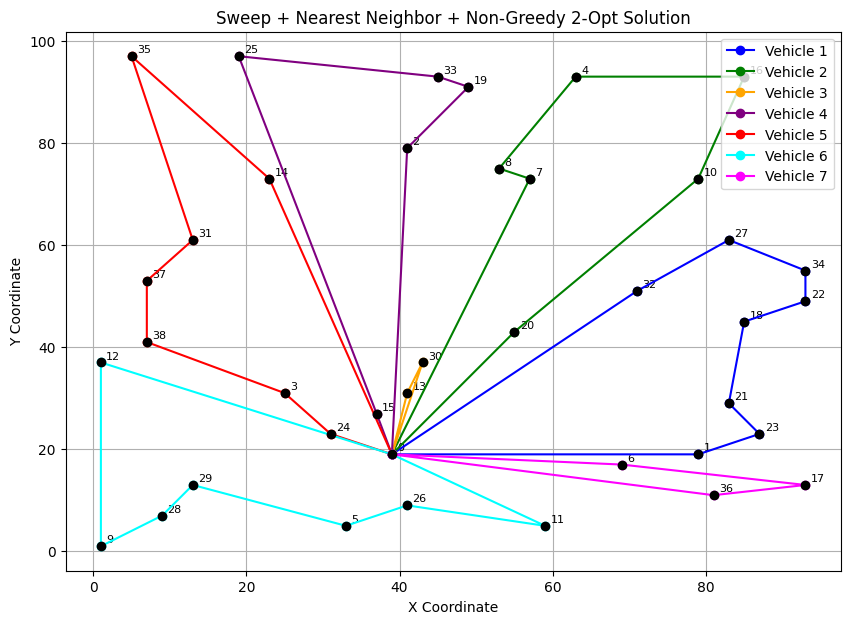

In [458]:
def plot_vrp_solution(coords, routes_dict, title):

    colors = ['blue', 'green', 'orange', 'purple', 'red', 'cyan', 'magenta']

    plt.figure(figsize=(10, 7))
    plt.scatter(coords[:, 0], coords[:, 1], c='black', zorder=5)

    for i, (x, y) in enumerate(coords):
        plt.text(x + 0.7, y + 0.7, str(i), fontsize=8)

    for i, route in routes_dict.items():
        route_coords = coords[route]
        plt.plot(route_coords[:, 0], route_coords[:, 1], marker='o',
                 label=f"Vehicle {i+1}", color=colors[i % len(colors)], zorder=3)

    plt.title(title)
    plt.xlabel("X Coordinate")
    plt.ylabel("Y Coordinate")
    plt.legend()
    plt.grid(True)
    plt.show()


plot_vrp_solution(coordinates, nongreedy_optimized_routes, "Sweep + Nearest Neighbor + Non-Greedy 2-Opt Solution")

In [459]:
def print_vehicle_loads(routes_dict, demands, vehicle_capacity):
    print("{:<10} | {:<60} | {}".format("Vehicle", "Route", "Load Utilization"))
    print("-" * 100)

    for vehicle_id, route in routes_dict.items():
        load = sum(demands[int(node)] for node in route if node != 0)
        utilization = round((load / vehicle_capacity) * 100, 1)
        route_str = " → ".join(str(node) for node in route)
        print(f"Vehicle {vehicle_id+1:<2} | Route: {route_str:<50} | Load: {load} / {vehicle_capacity} ({utilization}%)")
print_vehicle_loads(nongreedy_optimized_routes, demands, vehicle_capacity)

Vehicle    | Route                                                        | Load Utilization
----------------------------------------------------------------------------------------------------
Vehicle 1  | Route: 0 → 1 → 23 → 21 → 18 → 22 → 34 → 27 → 32 → 0       | Load: 84 / 85 (98.8%)
Vehicle 2  | Route: 0 → 20 → 10 → 16 → 4 → 8 → 7 → 0                   | Load: 78 / 85 (91.8%)
Vehicle 3  | Route: 0 → 13 → 30 → 0                                    | Load: 81 / 85 (95.3%)
Vehicle 4  | Route: 0 → 15 → 25 → 33 → 19 → 2 → 0                      | Load: 80 / 85 (94.1%)
Vehicle 5  | Route: 0 → 24 → 3 → 38 → 37 → 31 → 35 → 14 → 0            | Load: 80 / 85 (94.1%)
Vehicle 6  | Route: 0 → 11 → 26 → 5 → 29 → 28 → 9 → 12 → 0             | Load: 85 / 85 (100.0%)
Vehicle 7  | Route: 0 → 6 → 17 → 36 → 0                                | Load: 38 / 85 (44.7%)


In [460]:
print("\nNon-Greedy:")
for c in nongreedy_optimized_routes:
    print(nongreedy_optimized_routes[c])


Non-Greedy:
[0, 1, 23, 21, 18, 22, 34, 27, 32, 0]
[0, 20, 10, 16, 4, 8, 7, 0]
[0, 13, 30, 0]
[0, 15, 25, 33, 19, 2, 0]
[0, 24, 3, 38, 37, 31, 35, 14, 0]
[0, 11, 26, 5, 29, 28, 9, 12, 0]
[0, 6, 17, 36, 0]


SAVINGS


In [461]:
def calculate_tour_cost(tour, distance_matrix):
    cost = 0
    for i in range(len(tour)-1):
        cost += distance_matrix[tour[i]][tour[i+1]]
    return cost

start_time_savings = time.time()
def savings_algorithm_verbose(cluster, depot, distance_matrix, demands, vehicle_capacity):
    customers = list(cluster - {depot})
    routes = [[depot, c, depot] for c in customers]
    route_loads = {c: demands[c] for c in customers}

    savings = {}
    for i in customers:
        for j in customers:
            if i < j:
                s = distance_matrix[depot][i] + distance_matrix[depot][j] - distance_matrix[i][j]
                savings[(i, j)] = s
    savings_sorted = sorted(savings.items(), key=lambda x: x[1], reverse=True)

    for (i, j), _ in savings_sorted:
        r_i = None
        r_j = None
        for r in routes:
            if r[1] == i and r[-2] != j:
                r_i = r
            if r[1] == j and r[-2] != i:
                r_j = r
        if r_i and r_j and r_i != r_j:
            load_i = route_loads[r_i[1]]
            load_j = route_loads[r_j[1]]
            if load_i + load_j <= vehicle_capacity:
                new_route = r_i[:-1] + r_j[1:]
                routes.remove(r_i)
                routes.remove(r_j)
                routes.append(new_route)
                route_loads[new_route[1]] = load_i + load_j
                print(f"Merged routes ({i}, {j}) → New Route: {new_route}")
            else:
                print(f"Capacity exceeded for ({i}, {j}) → Load: {load_i + load_j}")
        else:
            print(f"No merging opportunity for ({i}, {j})")
    return routes
all_savings_routes = []
for cluster in clusters:
    result = savings_algorithm(cluster, depot=0, distance_matrix=distance_matrix, demands=demands, vehicle_capacity=85)
    all_savings_routes.extend(result)

end_time_savings = time.time()
total_time_savings = round(end_time_savings - start_time_savings, 5)
print(f"Total combination time: {total_time_savings} seconds")


savings_total_cost = 0


for i, cluster in enumerate(clusters):
    print(f"\nProcessing Cluster {i+1} → Nodes: {cluster}")
    routes = savings_algorithm_verbose(cluster, depot=0, distance_matrix=distance_matrix, demands=demands, vehicle_capacity=85)

for i, route in enumerate(all_savings_routes):
    cost = calculate_tour_cost(route, distance_matrix)
    savings_total_cost += cost
    print(f"Vehicle {i+1}: Route → {' → '.join(map(str, route))} | Cost = {cost:.2f}")

print(f"\nTotal combination time: {total_time_savings} seconds")
print(f"Total cost after Savings: {savings_total_cost:.2f}")
for i, r in enumerate(all_savings_routes):
    print(f"\nVehicle {i+1} → Route: {' → '.join(map(str, r))}")



Total combination time: 0.00099 seconds

Processing Cluster 1 → Nodes: {0, 1, 34, 32, 18, 21, 22, 23, 27}
Merged routes (22, 34) → New Route: [0, 22, 34, 0]
No merging opportunity for (27, 34)
Merged routes (22, 27) → New Route: [0, 22, 34, 27, 0]
Merged routes (18, 22) → New Route: [0, 18, 22, 34, 27, 0]
No merging opportunity for (18, 34)
No merging opportunity for (18, 27)
No merging opportunity for (27, 32)
No merging opportunity for (32, 34)
Merged routes (21, 23) → New Route: [0, 21, 23, 0]
No merging opportunity for (22, 32)
No merging opportunity for (21, 22)
No merging opportunity for (22, 23)
Merged routes (18, 32) → New Route: [0, 18, 22, 34, 27, 32, 0]
No merging opportunity for (21, 34)
Merged routes (18, 21) → New Route: [0, 18, 22, 34, 27, 32, 21, 23, 0]
No merging opportunity for (23, 34)
No merging opportunity for (1, 23)
No merging opportunity for (18, 23)
No merging opportunity for (1, 21)
No merging opportunity for (21, 27)
No merging opportunity for (23, 27)
No mer

In [462]:
start_time_reloc = time.time()
def relocate_algorithm(tour, distance_matrix):
    best_tour = tour[:]
    best_cost = calculate_tour_cost(best_tour, distance_matrix)

    improved = True
    while improved:
        improved = False
        for i in range(1, len(best_tour)-1):
            for j in range(1, len(best_tour)-1):
                if i == j:
                    continue
                new_tour = best_tour[:]
                node = new_tour.pop(i)
                new_tour.insert(j, node)
                new_cost = calculate_tour_cost(new_tour, distance_matrix)
                if new_cost < best_cost:
                    best_tour = new_tour[:]
                    best_cost = new_cost
                    improved = True
    return best_tour, best_cost

reloc_routes = []
reloc_total_cost = 0

for route in all_savings_routes:
    improved_route, cost = relocate_algorithm(route, distance_matrix)
    reloc_routes.append(improved_route)
    reloc_total_cost += cost

end_time_reloc = time.time()
total_time_reloc = round(end_time_reloc - start_time_reloc, 5)

improvement = round(100 * (savings_total_cost - reloc_total_cost) / savings_total_cost, 2)

print("\n--- Relocation Improvement (Sweep + Savings + Relocation) ---")
for i, route in enumerate(reloc_routes):
    print(f"Vehicle {i+1}: {' → '.join(map(str, route))} | New Cost: {calculate_tour_cost(route, distance_matrix):.2f}")

print(f"\nTotal cost after Relocation: {reloc_total_cost:.2f}")
print(f"Improvement from Savings-only: %{improvement}")
print(f"Relocation computation time: {total_time_reloc} seconds")



--- Relocation Improvement (Sweep + Savings + Relocation) ---
Vehicle 1: 0 → 32 → 27 → 34 → 22 → 18 → 21 → 23 → 1 → 0 | New Cost: 159.76
Vehicle 2: 0 → 7 → 8 → 4 → 16 → 10 → 20 → 0 | New Cost: 192.13
Vehicle 3: 0 → 13 → 30 → 0 | New Cost: 36.93
Vehicle 4: 0 → 2 → 19 → 33 → 25 → 15 → 0 | New Cost: 185.76
Vehicle 5: 0 → 14 → 35 → 31 → 37 → 38 → 3 → 24 → 0 | New Cost: 184.73
Vehicle 6: 0 → 12 → 29 → 28 → 9 → 5 → 26 → 11 → 0 | New Cost: 170.14
Vehicle 7: 0 → 6 → 17 → 36 → 0 | New Cost: 109.32

Total cost after Relocation: 1038.77
Improvement from Savings-only: %5.82
Relocation computation time: 0.00412 seconds


In [463]:
verify_vrp_solution(reloc_routes, df_demand["Demand"].values, 85, 38)


VRP solution is feasible! All conditions are satisfied.


True

In [464]:
reloc_routes_dict = {i: r for i, r in enumerate(reloc_routes)}

print_vehicle_loads(reloc_routes_dict, demands, vehicle_capacity)

Vehicle    | Route                                                        | Load Utilization
----------------------------------------------------------------------------------------------------
Vehicle 1  | Route: 0 → 32 → 27 → 34 → 22 → 18 → 21 → 23 → 1 → 0       | Load: 84 / 85 (98.8%)
Vehicle 2  | Route: 0 → 7 → 8 → 4 → 16 → 10 → 20 → 0                   | Load: 78 / 85 (91.8%)
Vehicle 3  | Route: 0 → 13 → 30 → 0                                    | Load: 81 / 85 (95.3%)
Vehicle 4  | Route: 0 → 2 → 19 → 33 → 25 → 15 → 0                      | Load: 80 / 85 (94.1%)
Vehicle 5  | Route: 0 → 14 → 35 → 31 → 37 → 38 → 3 → 24 → 0            | Load: 80 / 85 (94.1%)
Vehicle 6  | Route: 0 → 12 → 29 → 28 → 9 → 5 → 26 → 11 → 0             | Load: 85 / 85 (100.0%)
Vehicle 7  | Route: 0 → 6 → 17 → 36 → 0                                | Load: 38 / 85 (44.7%)


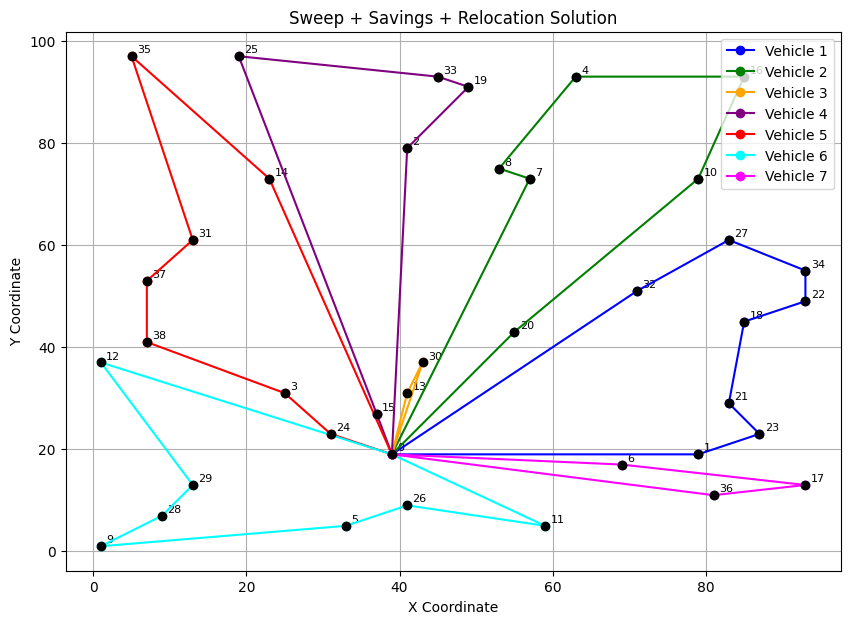

In [465]:
def plot_vrp_solution(coords, routes_dict, title):
    colors = ['blue', 'green', 'orange', 'purple', 'red', 'cyan', 'magenta']
    plt.figure(figsize=(10, 7))
    plt.scatter(coords[:, 0], coords[:, 1], c='black', zorder=5)

    for i, (x, y) in enumerate(coords):
        plt.text(x + 0.7, y + 0.7, str(i), fontsize=8)

    for i, route in routes_dict.items():
        route_coords = coords[route]
        plt.plot(route_coords[:, 0], route_coords[:, 1], marker='o',
                 label=f"Vehicle {i+1}", color=colors[i % len(colors)], zorder=3)

    plt.title(title)
    plt.xlabel("X Coordinate")
    plt.ylabel("Y Coordinate")
    plt.legend()
    plt.grid(True)
    plt.show()

reloc_routes_dict = {i: r for i, r in enumerate(reloc_routes)}

plot_vrp_solution(coordinates, reloc_routes_dict, "Sweep + Savings + Relocation Solution")


In [466]:
baseline_cost = max(nongreedy_total_cost, greedy_total_cost)

nongreedy_improvement = round(((baseline_cost - nongreedy_total_cost) / baseline_cost) * 100, 1)

results = [
    {
        "name": "NN + Non-Greedy 2-Opt",
        "cost": nongreedy_total_cost,
        "time": total_time_nongreedy2opt+total_time_nnh+total_time_sweep,
        "improvement": nongreedy_improvement
    },

    {
        "name": "Savings + Relocation",
        "cost": reloc_total_cost,
        "time": total_time_reloc+total_time_savings+total_time_sweep,
        "improvement": reloc_improvement
    }

]

def print_final_result_table(results):
    print("{:<30} {:<12} {:<12} {:<15}".format("Combination", "Total Cost", "Time (s)", "% Improvement"))
    print("-" * 75)
    for combo in results:
        name = combo["name"]
        cost = f"{combo['cost']:.2f}"
        time = f"{combo['time']:.5f}"
        improvement = f"{combo['improvement']:.5f}%"
        print(f"{name:<30} {cost:<12} {time:<12} {improvement:<15}")

print_final_result_table(results)


Combination                    Total Cost   Time (s)     % Improvement  
---------------------------------------------------------------------------
NN + Non-Greedy 2-Opt          1037.22      0.01280      0.60000%       
Savings + Relocation           1038.77      0.01218      5.82356%       


In [467]:
def inter_route_2exchange(routes, distance_matrix):

    if isinstance(routes[0], int):
        routes = [routes]

    best_routes = [list(r) for r in routes]
    best_cost = sum(calculate_tour_cost(r, distance_matrix) for r in best_routes)
    improved = True

    while improved:
        improved = False
        for i in range(len(best_routes)):
            for j in range(i + 1, len(best_routes)):
                route1 = best_routes[i]
                route2 = best_routes[j]

                for idx1 in range(1, len(route1) - 1):
                    for idx2 in range(1, len(route2) - 1):

                        new_route1 = list(route1)
                        new_route2 = list(route2)
                        new_route1[idx1], new_route2[idx2] = new_route2[idx2], new_route1[idx1]

                        new_cost1 = calculate_tour_cost(new_route1, distance_matrix)
                        new_cost2 = calculate_tour_cost(new_route2, distance_matrix)

                        other_cost = sum(
                            calculate_tour_cost(best_routes[k], distance_matrix)
                            for k in range(len(best_routes)) if k != i and k != j
                        )

                        new_total_cost = new_cost1 + new_cost2 + other_cost

                        if new_total_cost < best_cost:
                            best_cost = new_total_cost
                            best_routes[i] = new_route1
                            best_routes[j] = new_route2
                            improved = True

    return best_routes, best_cost


In [468]:
routes_list = list(nongreedy_optimized_routes.values())

nnh_2opt_2exchange_start = time.time()

nnh_2opt_2exchange_routes, nnh_2opt_2exchange_cost = inter_route_2exchange(
    routes_list, distance_matrix
)

nnh_2opt_2exchange_end = time.time()
nnh_2opt_2exchange_time = nnh_2opt_2exchange_end - nnh_2opt_2exchange_start


initial_total_cost = sum(nongreedy_optimized_costs.values())

improvement_nnh_2opt_2exchange = 100 * (initial_total_cost - nnh_2opt_2exchange_cost) / initial_total_cost

# SONUÇLARI YAZDIR
print(f"Before Cost (Sweep + NN + 2-Opt): {initial_total_cost:.3f}")
print(f"After 2-Exchange Cost           : {nnh_2opt_2exchange_cost:.3f}")
print(f"% Improvement (2-Exchange)     : {improvement_nnh_2opt_2exchange:.5f}%")
print(f"2-Exchange algorithm time      : {nnh_2opt_2exchange_time:.4f} seconds")


Before Cost (Sweep + NN + 2-Opt): 1037.224
After 2-Exchange Cost           : 995.040
% Improvement (2-Exchange)     : 4.06698%
2-Exchange algorithm time      : 0.0734 seconds
